# Tutorial: Simulating Qblox Schedules with QuTiP

This notebook demonstrates how to use the `QbloxQutipSimulator` to bridge the gap between high-level pulse scheduling (using `qblox-scheduler`) and low-level quantum dynamics simulation (using `QuTiP`).

## 1. Prerequisites
Ensure you have the following installed:
```bash
pip install qblox-scheduler qutip numpy pandas matplotlib scipy
```

In [1]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), 'src'))

import numpy as np
import matplotlib.pyplot as plt
import qutip
from qblox_scheduler import Schedule, HardwareAgent
from qblox_scheduler.operations import GaussPulse, SquarePulse, DRAGPulse, Measure
from qblox_scheduler.resources import ClockResource
from qblox_sim.simulator import QbloxQutipSimulator

%matplotlib inline

/opt/anaconda3/envs/blox_311/lib/python3.11/site-packages/quantify_core/utilities/general.py:13: QCoDeSDeprecationWarning: The `qcodes.utils.helpers` module is deprecated. Please consult the api documentation at https://microsoft.github.io/Qcodes/api/index.html for alternatives.
  from qcodes.utils.helpers import NumpyJSONEncoder


## 2. Defining the Qubit Model

First, we define the physical properties of our qubit. The simulator uses these parameters to construct the Hamiltonian and collapse operators ($T_1$, $T_2$).

In [2]:
qubit_params = {
    'f_q': 5.0e9,           # Qubit frequency: 5 GHz
    'f_d': 5.0e9,           # Drive frequency (on resonance)
    'rabi_freq_per_volt': 25e6, # 25 MHz per Volt drive strength
    'T1': 2e-6,            # 2 us relaxation time
    'T2': 1e-6,            # 1 us dephasing time
}
hardware_config_path = "config_files/hw_config.json"
device_config_path = "config_files/dut_config.json"

configs = {"hardware": hardware_config_path, "device": device_config_path}
sim = QbloxQutipSimulator(qubit_params, configs)
print("Simulator initialized with qubit frequency:", qubit_params['f_q'] / 1e9, "GHz")

Simulator initialized with qubit frequency: 5.0 GHz


## 3. Creating a Schedule

We use `qblox-scheduler` to define a simple experiment: a Rabi pulse followed by a measurement.

In [3]:
sched = Schedule("Rabi Tutorial")
sched.add_resource(ClockResource(name="q0.01", freq=qubit_params['f_q']))
sched.add_resource(ClockResource(name="q0.ro", freq=6.0e9))

# Add a Gauss pulse
pulse = sched.add(GaussPulse(amplitude=0.5, phase=0, duration=80e-9, port="q0:mw", clock="q0.01"))

# Add a measurement 10ns after the pulse
sched.add(Measure("q0", acq_index=0), rel_time=10e-9, ref_op=pulse, ref_pt="end")

print("Schedule created.")

Schedule created.


## 4. Running the Simulation

The `simulate()` method perform the following:
1. Resolves absolute timing of all operations.
2. Extracts pulse envelopes (I/Q) over time.
3. Constructs the time-dependent Hamiltonian $H(t)$.
4. Solves the Lindblad master equation using QuTiP's `mesolve`.

/opt/anaconda3/envs/blox_311/lib/python3.11/site-packages/qblox_scheduler/operations/acquisition_library.py:1481: FutureWarning: Using the `acq_index` argument is deprecated. Use the `coords` argument to define arbitrary user data for the acquisition. 
  warnings.warn(


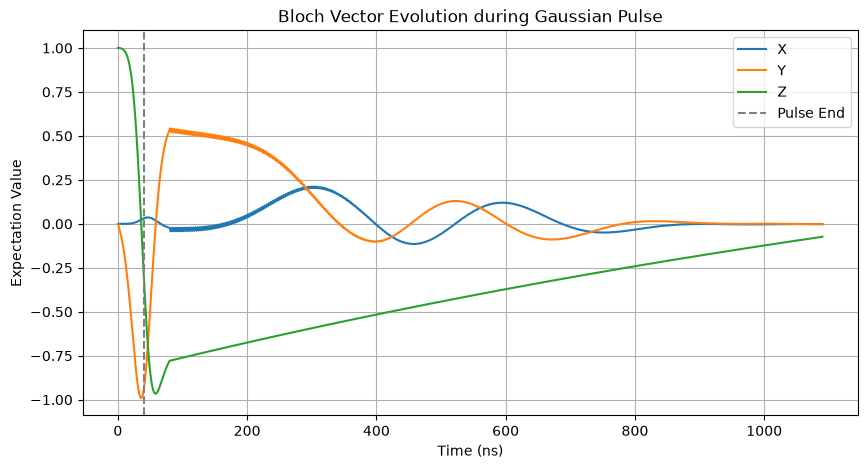

In [4]:
results = sim.simulate(sched)

t_list = results['t_list']
qubit_states = results['result'].states

# Calculate expectation values for Bloch sphere coordinates
expt_x = [qutip.expect(sim.sx, s).real for s in qubit_states]
expt_y = [qutip.expect(sim.sy, s).real for s in qubit_states]
expt_z = [qutip.expect(sim.sz, s).real for s in qubit_states]

plt.figure(figsize=(10, 5))
plt.plot(t_list * 1e9, expt_x, label='X')
plt.plot(t_list * 1e9, expt_y, label='Y')
plt.plot(t_list * 1e9, expt_z, label='Z')
plt.axvline(x=40, color='gray', linestyle='--', label='Pulse End')
plt.xlabel('Time (ns)')
plt.ylabel('Expectation Value')
plt.title('Bloch Vector Evolution during Gaussian Pulse')
plt.legend()
plt.grid(True)
plt.show()

## 5. Analyzing Measurement Outcomes

The simulator also extracts measurement probabilities at the exact time defined in the schedule.

In [5]:
if results['measurements']:
    meas = results['measurements'][0]
    print(f"Measurement Outcome: {meas['outcome']}")
    print(f"Probability of |1>: {meas['prob_1']:.4f}")

Measurement Outcome: 1
Probability of |1>: 0.8849


## 6. Advanced: Simulating Detuning

What happens if our drive frequency $f_d$ is slightly off from $f_q$? Let's simulate a 10 MHz detuning.

/opt/anaconda3/envs/blox_311/lib/python3.11/site-packages/qblox_scheduler/operations/acquisition_library.py:1481: FutureWarning: Using the `acq_index` argument is deprecated. Use the `coords` argument to define arbitrary user data for the acquisition. 
  warnings.warn(


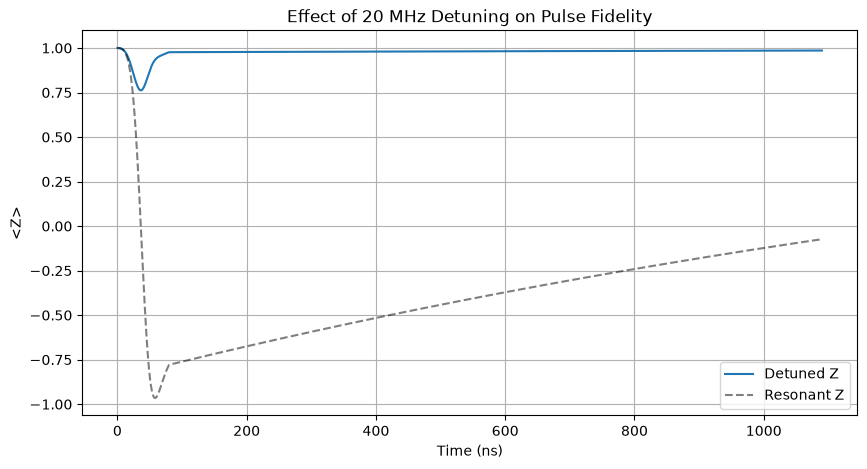

In [6]:
detuned_params = qubit_params.copy()
detuned_params['f_d'] = qubit_params['f_q'] + 20e6 # 20 MHz detuning

sim_detuned = QbloxQutipSimulator(detuned_params)
results_detuned = sim_detuned.simulate(sched)

plt.figure(figsize=(10, 5))
plt.plot(t_list * 1e9, [qutip.expect(sim.sz, s).real for s in results_detuned['result'].states], label='Detuned Z')
plt.plot(t_list * 1e9, expt_z, 'k--', alpha=0.5, label='Resonant Z')
plt.xlabel('Time (ns)')
plt.ylabel('<Z>')
plt.title('Effect of 20 MHz Detuning on Pulse Fidelity')
plt.legend()
plt.grid(True)
plt.show()

## 7. How the Hamiltonian is Constructed

The core of the simulator is the mapping of `Schedule` parameters to the Rotating Frame Hamiltonian:

$$H = \frac{\Delta}{2}\sigma_z + \frac{\Omega(t)}{2}(I(t)\sigma_x + Q(t)\sigma_y)$$

Where:
- $\Delta = 2\pi(f_q - f_d)$ is the detuning.
- $\Omega(t) = 2\pi \cdot \text{rabi\_freq\_per\_volt} \cdot A(t)$.
- $I(t) + iQ(t)$ is the complex envelope of the pulse.

This allows us to simulate not just simple square pulses, but arbitrary complex-valued waveforms like **DRAG** pulses which use the $Q$ channel to minimize leakage to higher states.

## 8. Proving the Gaussian Pulse Effect

Finally, we verify that the Gaussian pulse correctly manipulates the qubit by plotting the $\sigma_z$ expectation value as a function of the pulse duration.

Starting simulations for 40 different pulse durations...


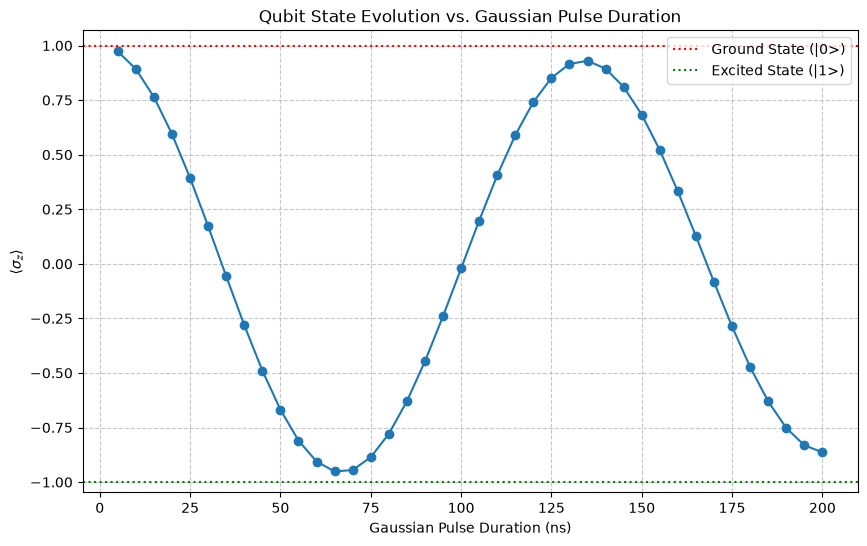

In [7]:
durations = np.linspace(5e-9, 200e-9, 40)
sz_expts = []

print(f"Starting simulations for {len(durations)} different pulse durations...")

for d in durations:
    sched_test = Schedule(f"Rabi_{d}")
    sched_test.add_resource(ClockResource(name="q0.01", freq=qubit_params['f_q']))
    
    # Add a Gauss pulse with amplitude 0.5
    sched_test.add(GaussPulse(amplitude=0.5, phase=0, duration=d, port="q0:mw", clock="q0.01"))
    
    results_test = sim.simulate(sched_test)
    final_state = results_test['result'].states[-1]
    
    sz_expt = qutip.expect(sim.sz, final_state)
    sz_expts.append(sz_expt)

plt.figure(figsize=(10, 6))
plt.plot(durations * 1e9, sz_expts, 'o-')
plt.xlabel('Gaussian Pulse Duration (ns)')
plt.ylabel(r'$\langle \sigma_z \rangle$')
plt.title('Qubit State Evolution vs. Gaussian Pulse Duration')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=1.0, color='r', linestyle=':', label='Ground State (|0>)')
plt.axhline(y=-1.0, color='g', linestyle=':', label='Excited State (|1>)')
plt.legend()
plt.show()

1. Overview
  The simulate function is the core of the QbloxQutipSimulator class. It bridges high-level pulse schedules defined via qblox-scheduler and low-level quantum dynamics simulation using QuTiP. It translates a
  series of scheduled pulses into a time-dependent Hamiltonian and solves the Lindblad master equation to predict the qubit's evolution.

  2. Step-by-Step Execution Flow

  ##### A. Schedule Compilation and Timing Resolution
  The function begins by calling _get_compiled_schedule(schedule). This step ensures that every operation in the Schedule has an absolute start time (abs_time) and duration. If the schedule is not already
  compiled, it uses a SerialCompiler with a dummy device to resolve timings.

  ##### B. Pulse and Acquisition Extraction
  The compiled timing_table is split into:
   * Pulses: Operations where is_acquisition == False (e.g., GaussPulse, SquarePulse).
   * Acquisitions: Operations where is_acquisition == True (e.g., Measure).

  The function then iterates through the pulses to extract physical parameters:
   * Amplitudes & Phases: Extracted from the pulse_info metadata.
   * Waveform Envelopes: Identified by wf_func (Square, Gauss, or DRAG).

  ##### C. Dynamics Setup
   * Time Axis (t_list): An array of time points from $t=0$ to the end of the last operation. The resolution is set to approximately 1ns or 500 points, whichever is higher.
   * Initial State: Defaults to the ground state $|0, 0\rangle$ in the joint Hilbert space of the qubit and the readout resonator.

  ##### D. Hamiltonian Construction
  The simulator constructs a time-dependent Hamiltonian $H(t)$ in the Rotating Frame:

   1. Static Part ($H_{static}$):
      $$H_{static} = \frac{\Delta}{2}\sigma_z + 2\pi\chi(a^\dagger a)\sigma_z$$
       * $\Delta = 2\pi(f_q - f_d)$ represents the detuning between the qubit and the drive.
       * The second term represents the dispersive coupling between the qubit and the resonator.

         The static part of the Hamiltonian describes the system's energy levels in the absence of external drives:
  $$H_{static} = \frac{\Delta}{2}\sigma_z + 2\pi\chi(a^\dagger a)\sigma_z$$

   * Detuning Term ($\frac{\Delta}{2}\sigma_z$):
      $\Delta = 2\pi(f_q - f_d)$ is the detuning between the qubit's natural frequency ($f_q$) and the drive frequency ($f_d$). In the rotating frame, the qubit appears to "precess" around the Z-axis at a
  rate proportional to this detuning. If the drive is perfectly on resonance ($\Delta = 0$), this term vanishes.
   * Dispersive Shift Term ($2\pi\chi n \sigma_z$):
      This term represents the interaction between the qubit and the readout resonator. $n = a^\dagger a$ is the photon number operator for the resonator. The physical effect is two-fold:
       1. The qubit frequency is shifted by $2\chi$ for every photon in the resonator.
       2. The resonator frequency is shifted by $\pm\chi$ depending on whether the qubit is in the $|0\rangle$ or $|1\rangle$ state. This shift is what enables non-destructive readout.

   2. Time-Dependent Drive Part:
      The drive terms are handled via QuTiP's list-string/function format:
      $$H_{drive}(t) = \frac{\Omega_q(t)}{2}(I_q(t)\sigma_x + Q_q(t)\sigma_y) + \frac{\Omega_{res}(t)}{2}(I_{res}(t)(a+a^\dagger) + Q_{res}(t)i(a^\dagger-a))$$
       * $\Omega(t)$ is scaled by rabi_freq_per_volt.
       * The get_drive helper function calculates the real ($I$) and imaginary ($Q$) components of the pulse envelopes at any time $t$ using the _pulse_envelope method.

   The drive part represents the external pulses applied to the system:
  $$H_{drive}(t) = \frac{\Omega_q(t)}{2}(I_q(t)\sigma_x + Q_q(t)\sigma_y) + \frac{\Omega_{res}(t)}{2}(I_{res}(t)(a+a^\dagger) + Q_{res}(t)i(a^\dagger-a))$$

   * Qubit Drive ($\sigma_x, \sigma_y$):
      External microwave pulses applied to the q0:mw port.
       * In-phase ($I_q$): Corresponds to the real part of the pulse envelope. It drives transitions around the X-axis of the Bloch sphere.
       * Quadrature ($Q_q$): Corresponds to the imaginary part. It drives transitions around the Y-axis.
       * Rabi Frequency ($\Omega_q$): Scaled by rabi_freq_per_volt. This maps the pulse amplitude in Volts to the physical rotation rate in rad/s.
   * Resonator Drive ($a+a^\dagger, i(a^\dagger-a)$):
      Used for readout pulses on the q0:res port.
       * The term $(a+a^\dagger)$ drives the displacement of the resonator field in the real quadrature, while $i(a^\dagger-a)$ drives the imaginary quadrature.

   
  3. Key Parameters
   * f_q: Qubit resonance frequency (Hz).
   * f_d: Microwave drive frequency (Hz).
   * chi: Dispersive coupling strength (Hz).
   * T1 / T2: Longitudinal and transverse relaxation times (s).
   * kappa: Resonator linewidth (Hz).
   * rabi_freq_per_volt: Mapping from pulse amplitude to Rabi frequency (Hz/V).

   The simulator operates in the Rotating Frame relative to the drive frequencies. This transformation simplifies the time-dependent Schrödinger equation by removing the rapid oscillations at the carrier
  frequency, allowing for much larger simulation time steps.



  ##### E. Dissipation and Master Equation Solving
  Collapse operators are defined for:
   * Relaxation ($T_1$): $\sqrt{1/T_1}\sigma_-$
   * Dephasing ($T_2$): $\sqrt{2\gamma_\phi}\sigma_z/2$
   * Resonator Decay ($\kappa$): $\sqrt{2\pi\kappa}a$

  The function calls qutip.mesolve to solve the Lindblad equation:
  $$\dot{\rho} = -i[H(t), \rho] + \sum_n L_n \rho L_n^\dagger - \frac{1}{2}\{L_n^\dagger L_n, \rho\}$$

  ##### F. Measurement and Return
  After the evolution, the function identifies the states at the times specified by acquisitions. For each measurement:
   * It performs a partial trace to get the qubit's reduced density matrix $\rho_q$.
   * It calculates the probability of being in the excited state $|1\rangle$.
   * It generates a random outcome (0 or 1) based on that probability.

  3. Return Structure
  The function returns a dictionary:
   * result: The full qutip.Result object containing states over time.
   * t_list: The time coordinates for the simulation.
   * measurements: A list of dictionaries containing name, time, prob_1, and outcome for each acquisition.


## 9. Simulating Loops

Qblox schedules often use loops for parameter sweeps (e.g., Rabi amplitude sweeps). The `QbloxLoopSimulator` is designed to handle these looped schedules by unrolling them and resolving variable parameters for each iteration.

In [9]:
from qblox_sim.simulator import QbloxLoopSimulator
from qblox_scheduler.operations import linspace, DType

# 1. Create a Schedule with a loop
loop_sched = Schedule("Rabi Amplitude Sweep")
loop_sched.add_resource(ClockResource(name="q0.01", freq=qubit_params['f_q']))

# Sweep amplitude from 0.0 to 1.0 in 11 steps
amp_domain = linspace(0.0, 1.0, 11, dtype=DType.AMPLITUDE)

with loop_sched.loop(amp_domain) as amp:
    # 40ns pulse with variable amplitude
    p = loop_sched.add(SquarePulse(amp=amp, duration=40e-9, port="q0:mw", clock="q0.01"))
    # 60ns wait
    loop_sched.add(SquarePulse(amp=0, duration=60e-9, port="q0:mw", clock="q0.01"), ref_op=p, ref_pt="end")

# 2. Initialize the Loop Simulator
loop_sim = QbloxLoopSimulator(qubit_params)

# 3. Run the simulation
print("Running looped simulation...")
loop_results = loop_sim.simulate(loop_sched)
print("Done.")

Running looped simulation...
Done.


### Visualizing the Looped Evolution

We can plot the expectation value of $\sigma_z$ over the entire duration of the looped schedule. Each "hump" in the plot represents a different pulse amplitude from the sweep.

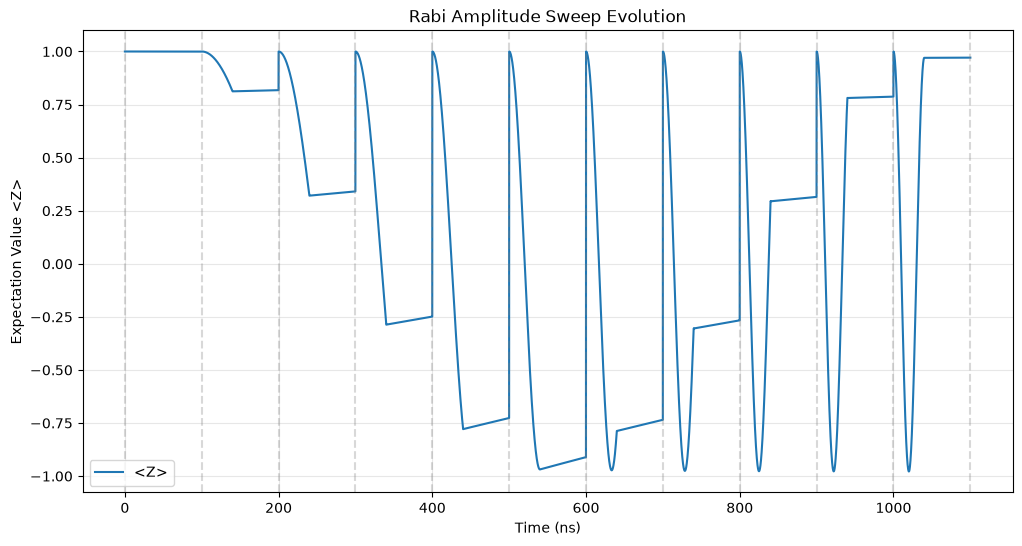

In [11]:
t_list_loop = loop_results['t_list']
result_loop = loop_results['result']

# Extract expectation value using the dimension-agnostic helper (N_q=2 or N_q>=3)
expt_z_loop = result_loop.get_expectation('sz')

plt.figure(figsize=(12, 6))
plt.plot(t_list_loop * 1e9, expt_z_loop, label='<Z>')

# Add vertical lines to show loop boundaries (every 100 ns)
for i in range(12):
    plt.axvline(x=i*100, color='gray', linestyle='--', alpha=0.3)

plt.xlabel('Time (ns)')
plt.ylabel('Expectation Value <Z>')
plt.title('Rabi Amplitude Sweep Evolution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 9.1 Rabi Amplitude Trace

Often we want to see the "trace" of the qubit state as a function of the swept parameter (amplitude) rather than the raw time evolution. We can extract the state at the end of each loop iteration to construct this plot.

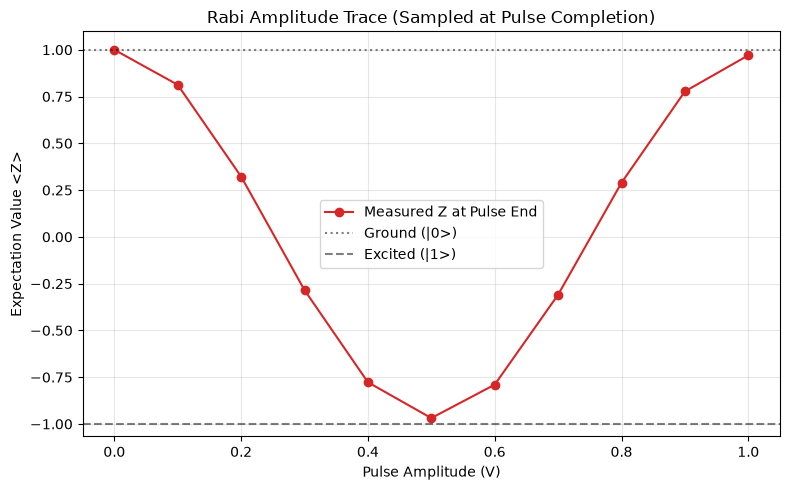

In [14]:
# 1. Extract amplitudes from the domain
amplitudes = np.linspace(0.0, 1.0, 11)

# 2. Extract Z expectation values across the entire stitched timeline
expt_z_all = result_loop.get_expectation('sz')

# 3. Sample Z right at the END of each 40ns pulse (40ns into each 100ns iteration)
pulse_duration = 40e-9
iteration_period = 100e-9
num_shots = len(amplitudes)

pulse_end_times = [i * iteration_period + pulse_duration for i in range(num_shots)]
trace_z = []

for end_time in pulse_end_times:
    # Find the state right at pulse completion before ground reset
    idx = np.argmin(np.abs(t_list_loop - end_time))
    trace_z.append(expt_z_all[idx])

# 4. Plot Rabi Oscillation Curve vs Amplitude
plt.figure(figsize=(8, 5))
plt.plot(amplitudes, trace_z, 'o-', color='tab:red', label='Measured Z at Pulse End')
plt.xlabel('Pulse Amplitude (V)')
plt.ylabel('Expectation Value <Z>')
plt.title('Rabi Amplitude Trace (Sampled at Pulse Completion)')
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='k', linestyle=':', alpha=0.5, label='Ground (|0>)')
plt.axhline(y=-1, color='k', linestyle='--', alpha=0.5, label='Excited (|1>)')
plt.legend()
plt.tight_layout()
plt.savefig('rabi_amplitude_trace_fixed.png')
plt.show()